This notebook plots the plot where all models are ranked

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-deep")
plt.rcParams.update(
    {
        "text.usetex": True,  # Use LaTeX for text rendering
        "font.family": "serif",  # Use serif font
        "font.serif": ["Computer Modern Roman"],  # Use default LaTeX font
    }
)

In [2]:
df_lstm = pd.read_csv("../Results/lstm_hyper_opt.csv")
df_rnn = pd.read_csv("../Results/rnn_hyper_opt.csv")
df_vqc = pd.read_csv("../Results/vqc_hyper_opt.csv")
df_mlp = pd.read_csv("../Results/mlp_hyper_opt.csv")
df_qrnn = pd.read_csv("../Results/qrnn_paper_hyper_opt.csv")
df_qlstm_paper = pd.read_csv("../Results/qlstm_paper_hyper_opt.csv")
df_qlstm_le = pd.read_csv("../Results/qlstm_linear_enhanced_paper_hyper_opt.csv")

In [3]:
df_vqc_reuploading_expencnorm = df_vqc[df_vqc["Ansatz"].str.startswith("ruexp_")]
df_vqc_dressed = df_vqc[df_vqc["Ansatz"].str.startswith("paper_rivera-ruiz_with_inputlayer_")]
df_qrnn_no_reset = df_qrnn[df_qrnn["Ansatz"] == "paper_no_reset"]

In [4]:
def find_best(df):
    df_intern = df.copy()
    best_rows = df_intern.loc[
        df_intern.groupby(["Prediction Step", "Data", "Sequence Length"], observed=True)[
            "MSE Validation Median"
        ].idxmin()
    ]
    return best_rows


best_lstm = find_best(df_lstm)
best_vqc_reuploading_expencnorm = find_best(df_vqc_reuploading_expencnorm)
best_vqc_dressed = find_best(df_vqc_dressed)
best_mlp = find_best(df_mlp)
best_qrnn_no_reset = find_best(df_qrnn_no_reset)
best_qlstm_paper = find_best(df_qlstm_paper)
best_rnn = find_best(df_rnn)
best_qlstm_le = find_best(df_qlstm_le)

In [5]:
sequence_lengths = [4, 8, 16]
prediction_steps_mackey = [1, 70, 140]
prediction_steps_henon = [1, 2, 4]
prediction_steps_lorenz = [1, 13, 25]

In [6]:
models = {
    "d-QNN": (best_vqc_dressed, "#CCB974"),
    "ru-QNN": (best_vqc_reuploading_expencnorm, "#8172B2"),
    "QRNN": (best_qrnn_no_reset, "#C44E52"),
    "QLSTM": (best_qlstm_paper, "#64B5CD"),
    "le-QLSTM": (best_qlstm_le, "#4C72B0"),
    "MLP": (best_mlp, "#E377C2"),
    "RNN": (best_rnn, "#55A868"),
    "LSTM": (best_lstm, "#8C564B"),
}

dataframes = []

# Add model name as a new column
for model_name, (df, color) in models.items():
    df_copy = df.copy()  # Avoid modifying the original DataFrame
    df_copy["Model Name"] = model_name
    dataframes.append(df_copy)

# Concatenate the DataFrames
results_df = pd.concat(dataframes, ignore_index=True)

results_df["Rank"] = results_df.groupby(["Sequence Length", "Data", "Prediction Step"])[
    "MSE Testing Median"
].rank(method="min")

# Sort the DataFrame for better visualization
results_df = results_df.sort_values(by=["Sequence Length", "Data", "Prediction Step", "Rank"])

# Count the number of times each model has rankings 1, 2, 3, 4, and 5
rank_counts = (
    results_df[results_df["Rank"] <= 9].groupby(["Model Name", "Rank"]).size().unstack(fill_value=0)
)

In [7]:
# Calculate the mean ranking for each model
mean_rankings = results_df.groupby("Model Name")["Rank"].mean()

# Sort the models by their mean rank
sorted_models = mean_rankings.sort_values(ascending=False).index

# Reorder rank_counts according to the sorted models
rank_counts_sorted = rank_counts.loc[sorted_models]

<Figure size 360x280 with 0 Axes>

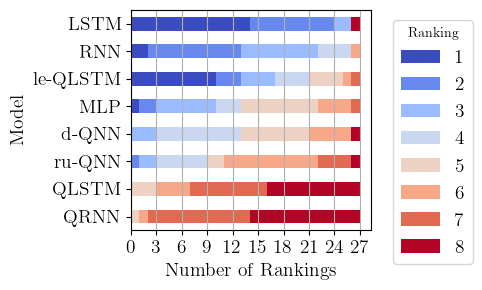

In [8]:
# Define a color map from red (worst place) to blue (best place)
cmap = plt.colormaps.get_cmap("coolwarm")
# Generate 9 evenly spaced colors from the colormap
colors = [cmap(i) for i in np.linspace(0, 1, 8)]  # change to np.linspace(0, 1, 9) for all models

# Sort the models by the number of rank 1 in descending order
# rank_counts = rank_counts.sort_values(by=[1.0, 2.0, 3.0, 4.0], ascending=[True, True, True, True])
plt.figure(figsize=(3.6, 2.8))
ax = rank_counts_sorted.plot(
    kind="barh", stacked=True, color=[colors[i] for i in range(8)], fontsize=14, figsize=(5, 3)
)  # change to range(9) for all models
plt.xlabel("Number of Rankings", fontsize=14)
plt.ylabel("Model", fontsize=14)

# Place the legend outside and set the labels as integers
handles, labels = ax.get_legend_handles_labels()
labels = [str(int(float(label))) for label in labels]  # Convert float labels to integers
ax.legend(handles, labels, title="Ranking", bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=14)
# ax.set_xticks(range(int(rank_counts.sum(axis=1).max() + 1)))  # Adjust the range based on your data
max_value = int(rank_counts.sum(axis=1).max() + 1)
xticks = np.arange(0, max_value + 1, 3)  # Create ticks every 2 units
ax.set_xticks(xticks)

# Enable grid only for x-axis
plt.grid(axis="x", which="major")
# Show the plot
plt.tight_layout()
plt.savefig(f"ranking_all_models_mse.pdf")